<a href="https://colab.research.google.com/github/Ozk18532/INTELIGENCIA-COMPUTACIONAL-Oscar-Mercado/blob/main/Vegetable_Fruit_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Curso:** Inteligencia Computacional

**Integrantes:**

Catalina Zavala Franco

Oscar A. Mercado Bibriesca

Rodrigo Amaro Gonzalez

**Profesor:** Ortega Muñoz, Luis

**Fecha:** 22 de abril de 2026

# Clasificación de plantas con CNN

## Definición del problema

Se busca desarrollar un modelo de aprendizaje automático capaz de clasificar imágenes de plantas en distintas categorías.

Este problema corresponde a **clasificación multiclase**, ya que el modelo debe asignar cada imagen a una única clase.

## Tipo de problema

- Tipo: Clasificación
- Input: Imagen
- Output: Etiqueta (tipo de planta)

Un modelo de clasificación predice categorías discretas a partir de datos de entrada. :contentReference[oaicite:0]{index=0}

## Objetivo

Construir una red neuronal convolucional (CNN) que aprenda patrones visuales como bordes, texturas y formas para distinguir entre distintas especies.

# Bloque 1. Instalación e importaciones
En este bloque se instalaron y cargaron las librerías necesarias para el proyecto. Se incluyeron herramientas para manejo de datos, entrenamiento con PyTorch, métricas de evaluación y exportación del modelo.

In [ ]:
!pip install -q kagglehub onnx onnxruntime

import os
import copy
import json
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
import kagglehub

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from google.colab import files

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 43.3 MB/s eta 0:00:00


# Bloque 2. Configuración base
En esta sección se definió la semilla para reproducibilidad y se detectó el dispositivo de trabajo. Esto permite ejecutar el entrenamiento en GPU cuando está disponible.

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


# Bloque 3. Carga del dataset
En este bloque se realizó la descarga del conjunto de datos desde KaggleHub y se definieron las rutas correspondientes a los subconjuntos de entrenamiento, validación y prueba.

El dataset utilizado se encuentra disponible en:
https://www.kaggle.com/datasets/yudhaislamisulistya/plants-type-datasets/data

Este conjunto contiene aproximadamente 30,000 imágenes distribuidas en 30 clases, organizadas en carpetas por categoría, lo que permite su uso directo en tareas de clasificación supervisada.

La separación en carpetas (train, validation y test) facilita la evaluación del modelo en diferentes etapas:

*  El conjunto de entrenamiento se utiliza para ajustar los parámetros del modelo.
*  El conjunto de validación permite monitorear el desempeño durante el entrenamiento.
*  El conjunto de prueba se utiliza para evaluar la capacidad de generalización en datos no vistos.

Esta división es importante para evitar overfitting y simular un entorno real de producción, donde el modelo debe predecir sobre datos nuevos

In [ ]:
path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")

data_dir = Path(path)

train_path = data_dir / "split_ttv_dataset_type_of_plants" / "Train_Set_Folder"
val_path = data_dir / "split_ttv_dataset_type_of_plants" / "Validation_Set_Folder"
test_path = data_dir / "split_ttv_dataset_type_of_plants" / "Test_Set_Folder"

print("Train:", train_path)
print("Val:", val_path)
print("Test:", test_path)

100%|██████████| 937M/937M [00:25<00:00, 39.0MB/s]

Extracting files...


Train: /root/.cache/kagglehub/datasets/yudhaislamisulistya/plants-type-datasets/versions/16/split_ttv_dataset_type_of_plants/Train_Set_Folder
Val: /root/.cache/kagglehub/datasets/yudhaislamisulistya/plants-type-datasets/versions/16/split_ttv_dataset_type_of_plants/Validation_Set_Folder
Test: /root/.cache/kagglehub/datasets/yudhaislamisulistya/plants-type-datasets/versions/16/split_ttv_dataset_type_of_plants/Test_Set_Folder


# Bloque 4. Preprocesamiento
En este bloque se definieron las transformaciones aplicadas a las imágenes antes de entrar al modelo. Se utilizó un preprocesamiento básico y otro específico para ResNet18 con normalización tipo ImageNet.

In [ ]:
img_size = 224
batch_size = 32

transform_basic = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor()
])

transform_resnet = transforms.Compose([#⚠️
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Bloque 5. Datasets y DataLoaders para EDA
En esta parte se crearon los datasets y DataLoaders iniciales para realizar el análisis exploratorio. También se obtuvieron las clases y el número total de categorías del problema.

In [ ]:
train_dataset_eda = datasets.ImageFolder(train_path, transform=transform_basic)
val_dataset_eda = datasets.ImageFolder(val_path, transform=transform_basic)
test_dataset_eda = datasets.ImageFolder(test_path, transform=transform_basic)

class_names = train_dataset_eda.classes#⚠️
num_classes = len(class_names)

print("Número de clases:", num_classes)
print("Clases:", class_names)
print("Train:", len(train_dataset_eda))
print("Validation:", len(val_dataset_eda))
print("Test:", len(test_dataset_eda))

Número de clases: 30
Clases: ['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant', 'galangal', 'ginger', 'guava', 'kale', 'longbeans', 'mango', 'melon', 'orange', 'paddy', 'papaya', 'peper chili', 'pineapple', 'pomelo', 'shallot', 'soybeans', 'spinach', 'sweet potatoes', 'tobacco', 'waterapple', 'watermelon']
Train: 23972
Validation: 3030
Test: 2998


# Bloque 6. EDA: distribución por clase
Aquí se analizó la cantidad de imágenes por clase en train, validation y test. Esto permitió verificar si el conjunto estaba balanceado.






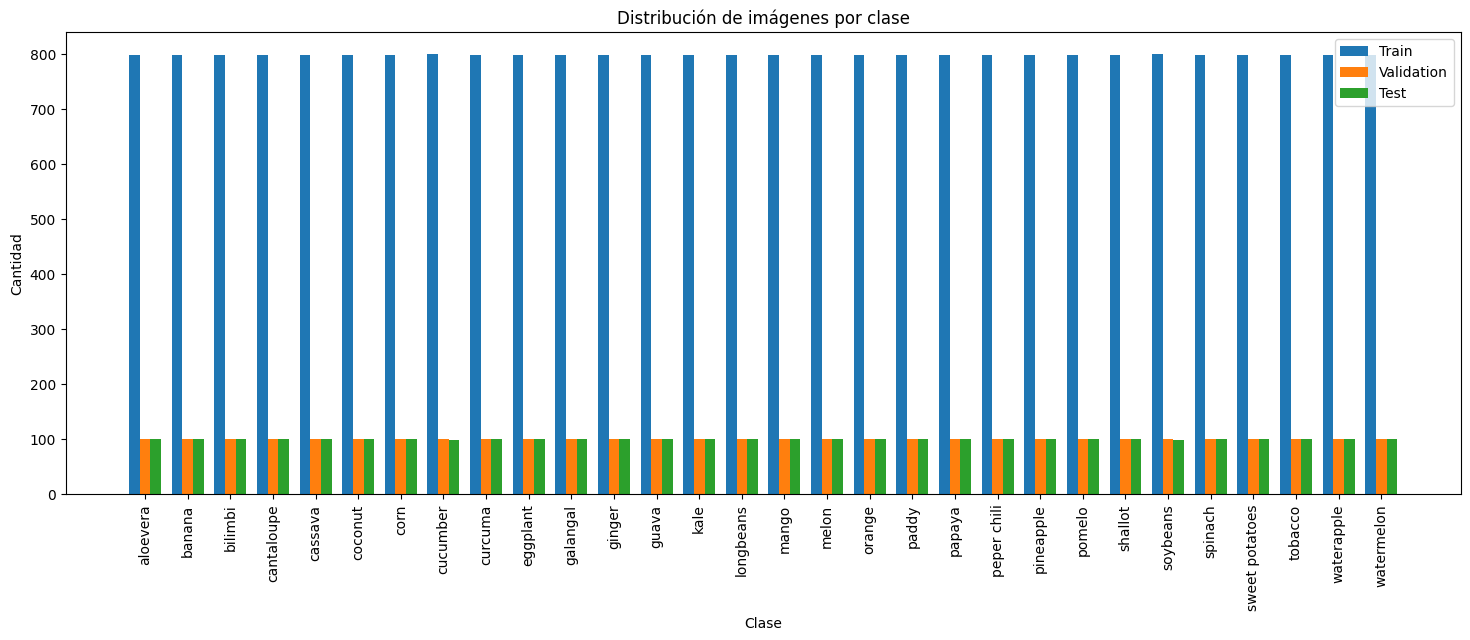

In [ ]:
from collections import Counter

train_counts = Counter([label for _, label in train_dataset_eda.samples])
val_counts = Counter([label for _, label in val_dataset_eda.samples])
test_counts = Counter([label for _, label in test_dataset_eda.samples])

train_class_counts = [train_counts[i] for i in range(num_classes)]
val_class_counts = [val_counts[i] for i in range(num_classes)]
test_class_counts = [test_counts[i] for i in range(num_classes)]

x = np.arange(num_classes)
width = 0.25

plt.figure(figsize=(18, 6))#⚠️
plt.bar(x - width, train_class_counts, width=width, label="Train")
plt.bar(x, val_class_counts, width=width, label="Validation")
plt.bar(x + width, test_class_counts, width=width, label="Test")
plt.xticks(x, class_names, rotation=90)
plt.title("Distribución de imágenes por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.legend()
plt.show()

# Bloque 7. EDA: mostrar imágenes de ejemplo
En este bloque se visualizaron imágenes representativas de distintas clases. Esto ayudó a confirmar que los datos fueron cargados correctamente y que las etiquetas coincidían con el contenido visual.

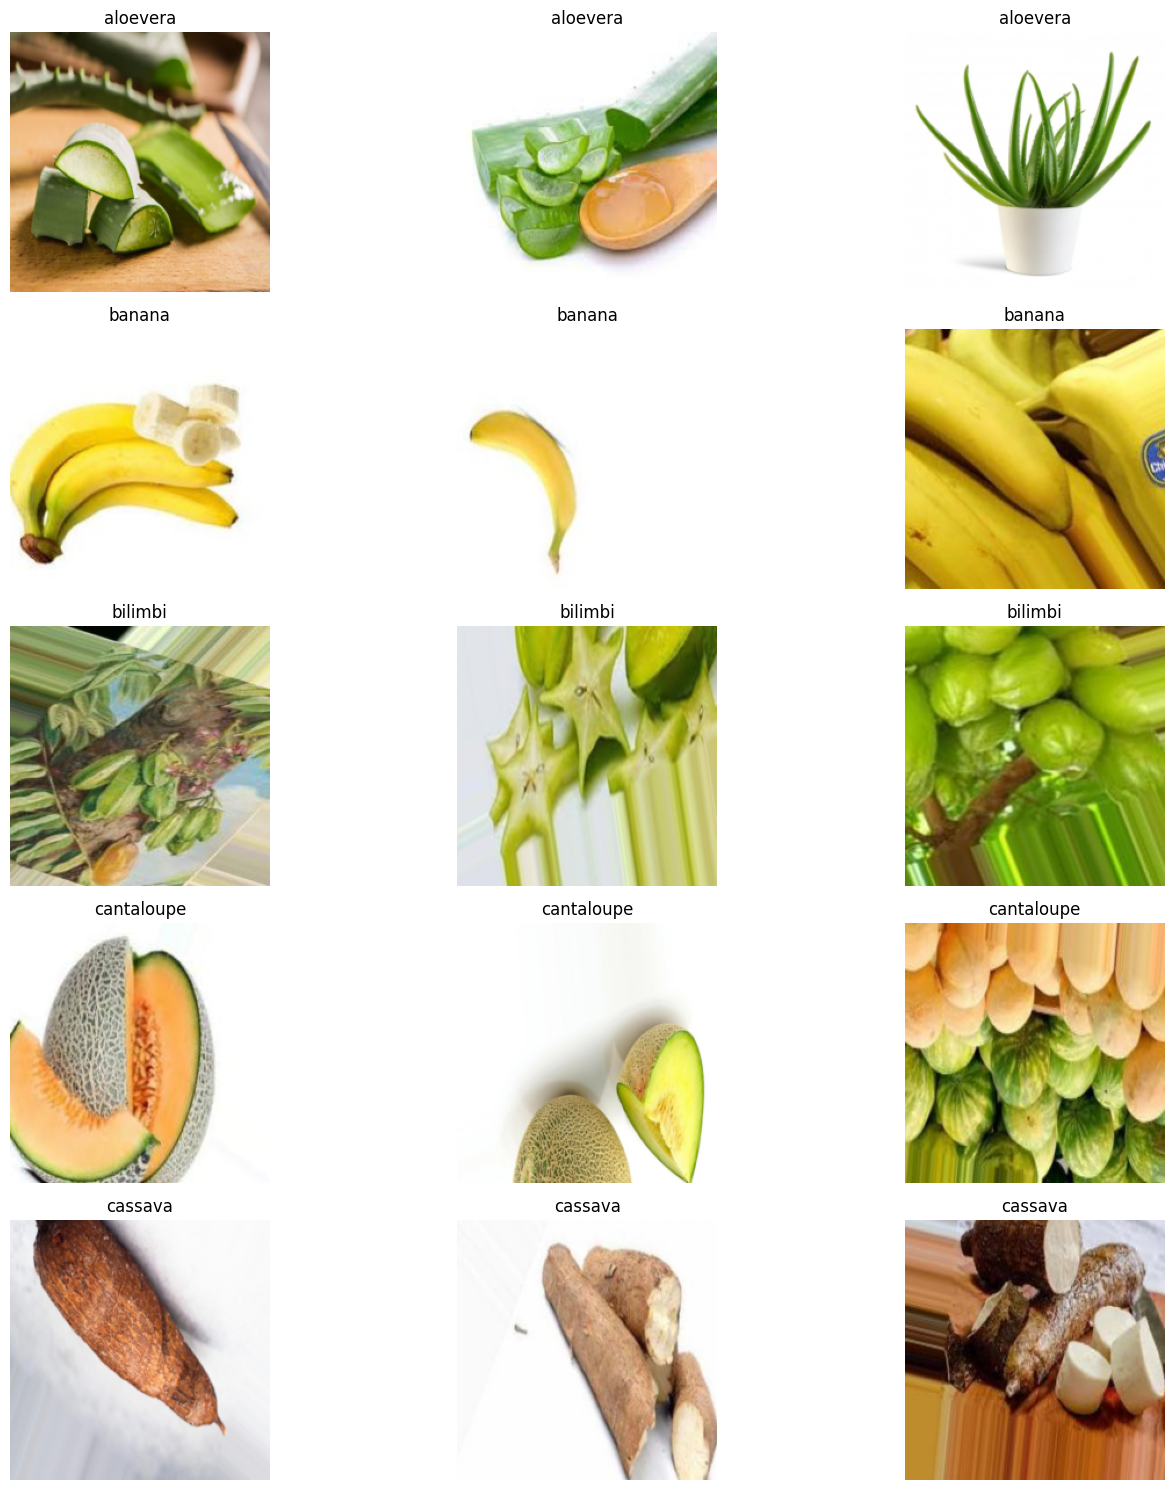

In [ ]:
def show_samples(dataset, class_names, samples_per_class=3):
    plt.figure(figsize=(15, 3 * len(class_names[:5])))
    shown = {i: 0 for i in range(len(class_names))}
    plot_idx = 1

    for img, label in dataset:
        if shown[label] < samples_per_class and label < min(5, len(class_names)):
            plt.subplot(min(5, len(class_names)), samples_per_class, plot_idx)
            img_np = img.permute(1, 2, 0).numpy()
            plt.imshow(img_np)
            plt.title(class_names[label])
            plt.axis("off")
            shown[label] += 1
            plot_idx += 1

        if all(shown[i] >= samples_per_class for i in range(min(5, len(class_names)))):
            break

    plt.tight_layout()
    plt.show()

show_samples(train_dataset_eda, class_names, samples_per_class=3)#⚠️

# Bloque 8. Datasets y DataLoaders finales para entrenamiento
Aquí se prepararon los DataLoaders definitivos para entrenar los modelos. Se separó el flujo para las CNN básicas y para ResNet18, debido a sus diferencias de preprocesamiento.

In [ ]:
# Para CNN_1 y CNN_2
train_dataset_basic = datasets.ImageFolder(train_path, transform=transform_basic)
val_dataset_basic = datasets.ImageFolder(val_path, transform=transform_basic)
test_dataset_basic = datasets.ImageFolder(test_path, transform=transform_basic)

train_loader_basic = DataLoader(train_dataset_basic, batch_size=batch_size, shuffle=True)#⚠️
val_loader_basic = DataLoader(val_dataset_basic, batch_size=batch_size, shuffle=False)
test_loader_basic = DataLoader(test_dataset_basic, batch_size=batch_size, shuffle=False)

# Para ResNet18
train_dataset_resnet = datasets.ImageFolder(train_path, transform=transform_resnet)#⚠️
val_dataset_resnet = datasets.ImageFolder(val_path, transform=transform_resnet)
test_dataset_resnet = datasets.ImageFolder(test_path, transform=transform_resnet)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle=True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle=False)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=batch_size, shuffle=False)

# Bloque 9. Modelo 1: CNN básica
En esta sección se definió la primera arquitectura, una red convolucional simple. Su propósito fue servir como modelo base para comparar rendimiento.

In [ ]:
class CNN_1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(#⚠️
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 112 * 112, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Bloque 10. Modelo 2: CNN intermedia
Aquí se construyó una segunda arquitectura convolucional con mayor profundidad. Este modelo buscó capturar características más complejas que la CNN básica.

In [ ]:
class CNN_2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()#⚠️
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Bloque 11. Modelo 3: ResNet18 preentrenado
En este bloque se utilizó ResNet18 con pesos preentrenados. Solo se reemplazó la última capa para adaptarla al número de clases del dataset.

In [ ]:
def build_resnet18(num_classes):
    model = models.resnet18(pretrained=True)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features#⚠️
    model.fc = nn.Linear(in_features, num_classes)

    return model

# Bloque 12. Función de entrenamiento y validación
Aquí se implementó la función principal de entrenamiento. En cada época se calcularon pérdida y accuracy en train y validation para seguir el desempeño del modelo.



In [ ]:
def train_model(model, train_loader, val_loader, epochs=5, lr=0.001, weight_decay=1e-4, only_fc=False):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    if only_fc:
        optimizer = optim.Adam(model.fc.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        # Train
        model.train()
        running_loss = 0.0
        y_true_train = []
        y_pred_train = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            y_true_train.extend(labels.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())

        epoch_train_loss = running_loss / len(train_loader.dataset)#⚠️
        epoch_train_acc = accuracy_score(y_true_train, y_pred_train)

        # Validation
        model.eval()
        running_val_loss = 0.0
        y_true_val = []
        y_pred_val = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)

                y_true_val.extend(labels.cpu().numpy())
                y_pred_val.extend(preds.cpu().numpy())

        epoch_val_loss = running_val_loss / len(val_loader.dataset)#⚠️
        epoch_val_acc = accuracy_score(y_true_val, y_pred_val)

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
        )

    model.load_state_dict(best_model_wts)
    return model, history, best_val_acc

# Bloque 13. Función para graficar curvas de aprendizaje
En esta parte se creó una función para mostrar las curvas de pérdida y exactitud. Estas gráficas permiten comparar el comportamiento del modelo entre entrenamiento y validación.

In [ ]:
def plot_learning_curves(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)#⚠️
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Bloque 14. Entrenar Modelo 1
En este bloque se entrenó la CNN básica. Después del entrenamiento, se graficaron sus curvas y se registró su mejor accuracy en validación.

Epoch 1/5 | Train Loss: 2.8428 | Train Acc: 0.2804 | Val Loss: 2.3584 | Val Acc: 0.3221
Epoch 2/5 | Train Loss: 1.7692 | Train Acc: 0.4895 | Val Loss: 2.1839 | Val Acc: 0.3746
Epoch 3/5 | Train Loss: 1.1934 | Train Acc: 0.6687 | Val Loss: 2.3631 | Val Acc: 0.3614
Epoch 4/5 | Train Loss: 0.7436 | Train Acc: 0.8084 | Val Loss: 2.6246 | Val Acc: 0.3393
Epoch 5/5 | Train Loss: 0.4928 | Train Acc: 0.8819 | Val Loss: 2.8657 | Val Acc: 0.3228


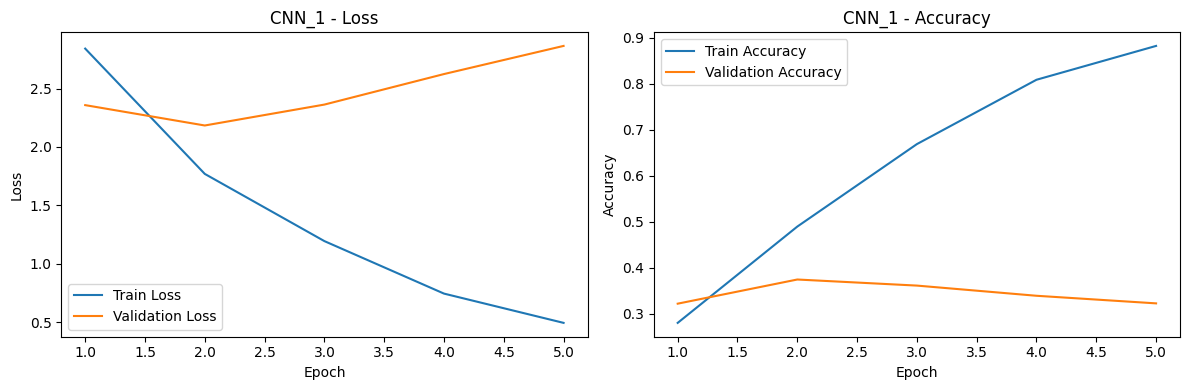

Best Val Acc CNN_1: 0.37458745874587457


In [ ]:
model1 = CNN_1(num_classes)
model1, history1, best_val_acc1 = train_model(
    model1,
    train_loader_basic,
    val_loader_basic,
    epochs=5,
    lr=0.001,
    weight_decay=1e-4,
    only_fc=False
)

plot_learning_curves(history1, "CNN_1")
print("Best Val Acc CNN_1:", best_val_acc1)

# Bloque 15. Entrenar Modelo 2
Aquí se entrenó la CNN intermedia. También se generaron sus curvas de aprendizaje y se guardó su mejor resultado en validation.

Epoch 1/5 | Train Loss: 2.3530 | Train Acc: 0.2902 | Val Loss: 1.9937 | Val Acc: 0.3677
Epoch 2/5 | Train Loss: 1.7875 | Train Acc: 0.4389 | Val Loss: 1.7726 | Val Acc: 0.4350
Epoch 3/5 | Train Loss: 1.5184 | Train Acc: 0.5169 | Val Loss: 1.6962 | Val Acc: 0.4670
Epoch 4/5 | Train Loss: 1.2570 | Train Acc: 0.6000 | Val Loss: 1.6444 | Val Acc: 0.4875
Epoch 5/5 | Train Loss: 0.9695 | Train Acc: 0.6887 | Val Loss: 1.8602 | Val Acc: 0.4564


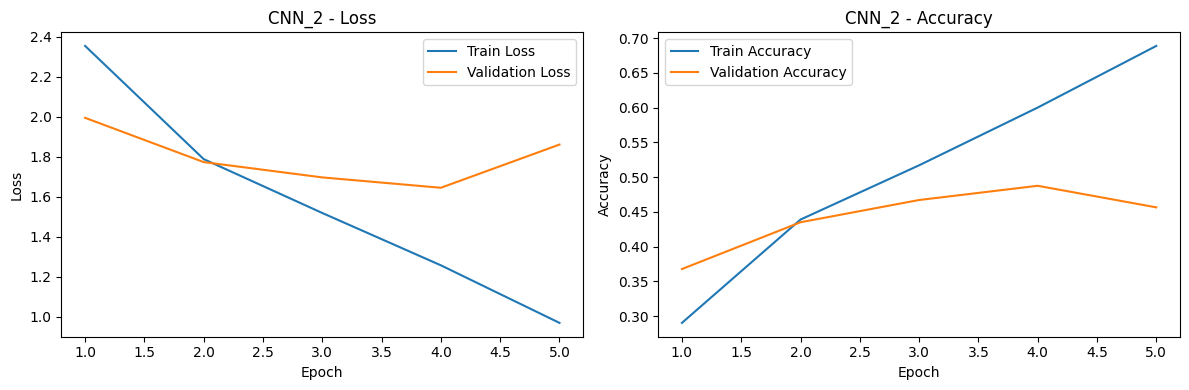

Best Val Acc CNN_2: 0.4874587458745875


In [ ]:
model2 = CNN_2(num_classes)
model2, history2, best_val_acc2 = train_model(#⚠️
    model2,
    train_loader_basic,
    val_loader_basic,
    epochs=5,
    lr=0.001,
    weight_decay=1e-4,
    only_fc=False
)

plot_learning_curves(history2, "CNN_2")
print("Best Val Acc CNN_2:", best_val_acc2)

# Bloque 16. Entrenar Modelo 3
En esta sección se entrenó ResNet18 preentrenado. Este modelo obtuvo el mejor desempeño entre las tres arquitecturas probadas.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Epoch 1/5 | Train Loss: 1.1058 | Train Acc: 0.7190 | Val Loss: 0.5658 | Val Acc: 0.8403
Epoch 2/5 | Train Loss: 0.5357 | Train Acc: 0.8478 | Val Loss: 0.4382 | Val Acc: 0.8680
Epoch 3/5 | Train Loss: 0.4349 | Train Acc: 0.8712 | Val Loss: 0.3805 | Val Acc: 0.8795
Epoch 4/5 | Train Loss: 0.3807 | Train Acc: 0.8828 | Val Loss: 0.3569 | Val Acc: 0.8848
Epoch 5/5 | Train Loss: 0.3487 | Train Acc: 0.8902 | Val Loss: 0.3226 | Val Acc: 0.8934


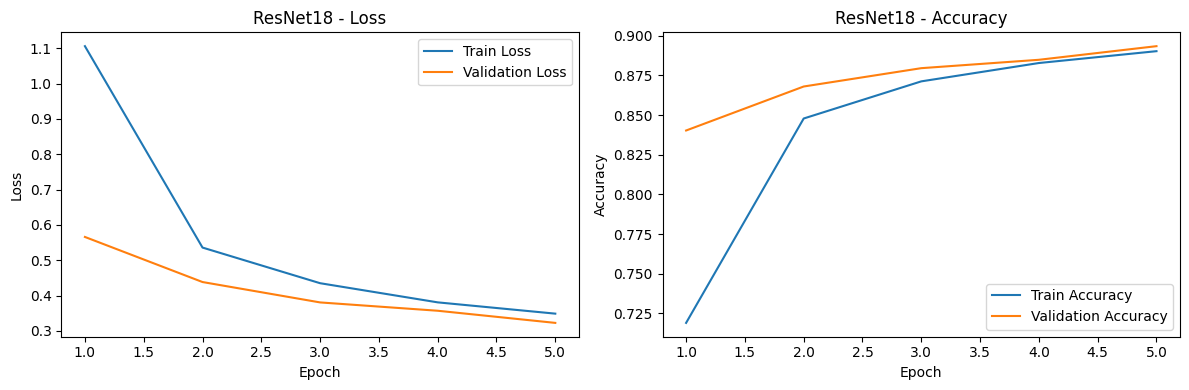

Best Val Acc ResNet18: 0.8933993399339935


In [ ]:
model3 = build_resnet18(num_classes)
model3, history3, best_val_acc3 = train_model(#⚠️
    model3,
    train_loader_resnet,
    val_loader_resnet,
    epochs=5,
    lr=0.001,
    weight_decay=1e-4,
    only_fc=True
)

plot_learning_curves(history3, "ResNet18")
print("Best Val Acc ResNet18:", best_val_acc3)

# Bloque 17. Comparación de modelos
Aquí se compararon los mejores resultados de validation de cada arquitectura. Esta revisión permitió identificar cuál modelo generalizó mejor.



In [ ]:
results = {
    "CNN_1": best_val_acc1,
    "CNN_2": best_val_acc2,
    "ResNet18": best_val_acc3
}

print(results)

best_model_name = max(results, key=results.get)#⚠️
print("Mejor modelo por validation:", best_model_name)

{'CNN_1': 0.37458745874587457, 'CNN_2': 0.4874587458745875, 'ResNet18': 0.8933993399339935}
Mejor modelo por validation: ResNet18


# Bloque 18. Selección del mejor modelo y loader correcto
En este bloque se seleccionó automáticamente el mejor modelo según validation accuracy. También se asignó el DataLoader y tipo de transformación correspondiente.

In [ ]:
if best_model_name == "CNN_1":
    best_model = model1
    best_history = history1
    best_test_loader = test_loader_basic
    best_transform_name = "basic"
elif best_model_name == "CNN_2":#⚠️
    best_model = model2
    best_history = history2
    best_test_loader = test_loader_basic
    best_transform_name = "basic"
else:
    best_model = model3#⚠️
    best_history = history3
    best_test_loader = test_loader_resnet
    best_transform_name = "resnet"

print("Transformación del mejor modelo:", best_transform_name)

Transformación del mejor modelo: resnet


# Bloque 19. Evaluación final en test
Aquí se evaluó el mejor modelo usando el conjunto de prueba. Se calcularon métricas globales y se generó el reporte de clasificación junto con la matriz de confusión.

Accuracy : 0.9039
Precision: 0.9069
Recall   : 0.9039
F1-score : 0.9032

Classification Report:

                precision    recall  f1-score   support

      aloevera       0.90      0.91      0.91       100
        banana       1.00      0.90      0.95       100
       bilimbi       0.93      0.92      0.92       100
    cantaloupe       0.70      0.81      0.75       100
       cassava       0.91      0.98      0.94       100
       coconut       0.87      0.85      0.86       100
          corn       0.97      0.92      0.94       100
      cucumber       0.93      0.94      0.93        99
       curcuma       0.86      0.92      0.89       100
      eggplant       0.97      0.96      0.96       100
      galangal       0.92      0.92      0.92       100
        ginger       0.86      0.87      0.87       100
         guava       0.90      0.90      0.90       100
          kale       0.96      0.82      0.89       100
     longbeans       0.92      0.95      0.94       100
      

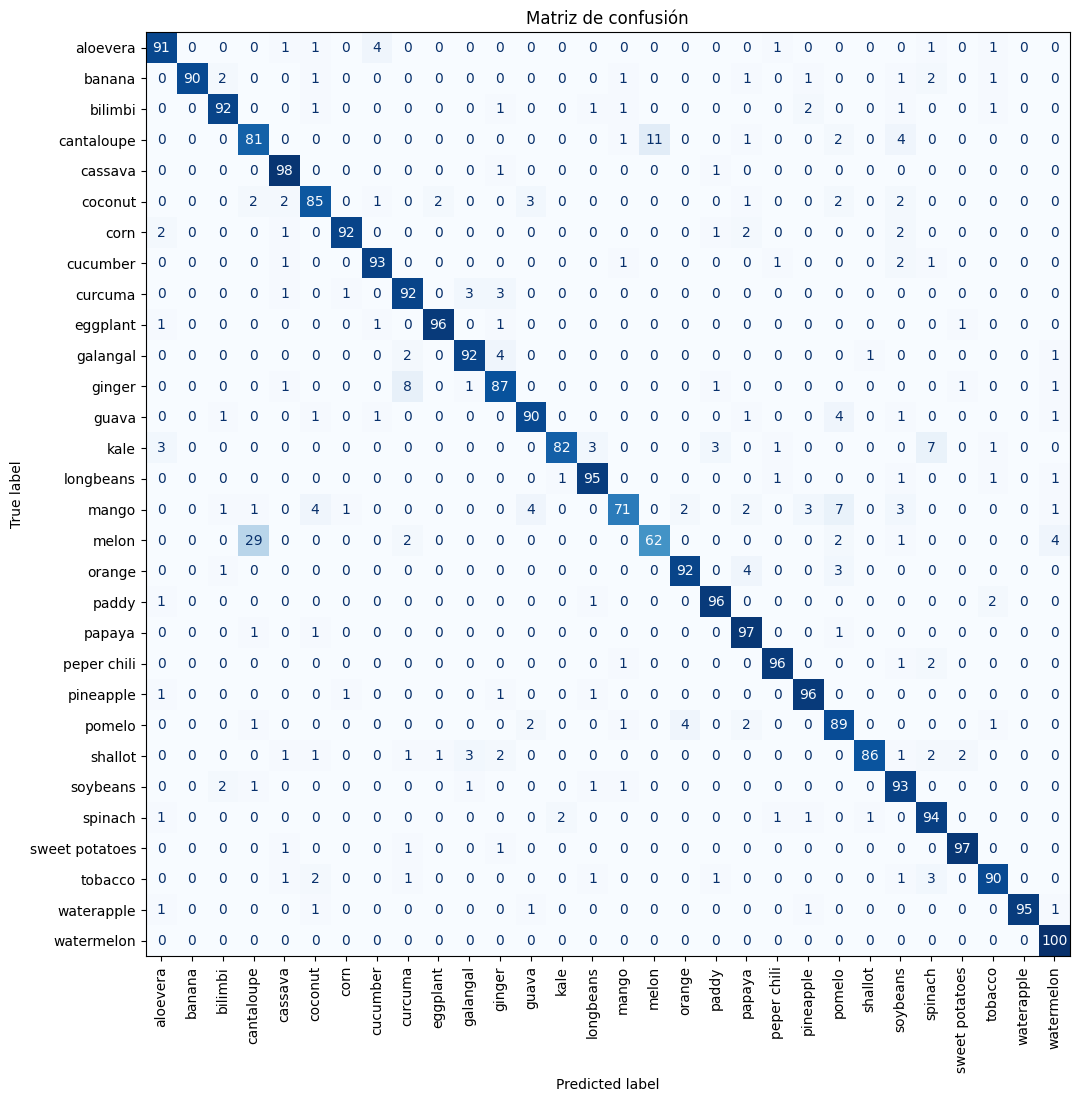

In [ ]:
def evaluate_model(model, loader, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)#⚠️
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)#⚠️
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(12, 12))
    disp.plot(ax=ax, xticks_rotation=90, cmap="Blues", colorbar=False)
    plt.title("Matriz de confusión")
    plt.show()

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

test_metrics = evaluate_model(best_model, best_test_loader, class_names)

# Bloque 20. Revisión simple de overfitting
En esta sección se comparó el accuracy final de train y validation. La diferencia entre ambos valores permitió revisar si existía sobreajuste.

In [ ]:
final_train_acc = best_history["train_acc"][-1]
final_val_acc = best_history["val_acc"][-1]
gap = final_train_acc - final_val_acc

print("Train accuracy final:", final_train_acc)
print("Validation accuracy final:", final_val_acc)
print("Brecha train-val:", gap)

if gap > 0.10:
    print("Posible overfitting: la brecha es considerable.")
else:
    print("No se observa una brecha grande entre train y validation.")

Train accuracy final: 0.8902469547805774
Validation accuracy final: 0.8933993399339935
Brecha train-val: -0.003152385153416093
No se observa una brecha grande entre train y validation.


# Bloque 21. Guardar etiquetas y metadatos
Aquí se almacenó información útil del proyecto en un archivo JSON. Se guardaron las clases, el tamaño de imagen, el mejor modelo y el tipo de transformación usada.

In [ ]:
metadata = {
    "class_names": class_names,
    "img_size": img_size,
    "best_model_name": best_model_name,
    "transform": best_transform_name
}

with open("metadata.json", "w") as f:
    json.dump(metadata, f)

print("metadata.json guardado")

metadata.json guardado


# Bloque 22. Guardar modelo en PyTorch
En este bloque se serializó el modelo final en formato `.pth`. Esto permite reutilizar los pesos aprendidos sin volver a entrenar la red.

In [ ]:
torch.save(best_model.state_dict(), "best_model.pth")
print("best_model.pth guardado")

best_model.pth guardado


# Bloque 23. Exportar el mejor modelo a ONNX
Aquí se instalaron las dependencias necesarias para exportar el modelo. Después, el modelo se preparó en modo evaluación para convertirlo a formato ONNX.

In [ ]:
!pip install -q onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 15.0 MB/s eta 0:00:00


In [ ]:
best_model.eval()

dummy_input = torch.randn(1, 3, img_size, img_size).to(device)#⚠️

torch.onnx.export(
    best_model,
    dummy_input,
    "best_model.onnx",
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    }
)

print("best_model.onnx exportado correctamente")

/tmp/ipykernel_1152/2489534051.py:5: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0423 18:05:08.504000 1152 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0423 18:05:09.831000 1152 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = 

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:68: adapt: Asserti

[torch.onnx] Translate the graph into ONNX... ✅
best_model.onnx exportado correctamente


# Bloque 24. Verificar el archivo ONNX
En esta sección se revisó que el archivo exportado a ONNX fuera válido. Esta comprobación asegura que el modelo puede usarse correctamente fuera de PyTorch.

In [ ]:
import onnx

onnx_model = onnx.load("best_model.onnx")
onnx.checker.check_model(onnx_model)

print("El modelo ONNX es válido")

El modelo ONNX es válido


# Bloque 25. Probar inferencia con ONNX Runtime
Aquí se realizó una prueba de inferencia utilizando ONNX Runtime. El objetivo fue confirmar que el modelo exportado produce predicciones correctamente.

In [ ]:
import onnxruntime as ort

session = ort.InferenceSession("best_model.onnx")#⚠️
input_name = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name

sample_batch, sample_labels = next(iter(best_test_loader))
sample_input = sample_batch[:1].numpy().astype(np.float32)

outputs = session.run([output_name], {input_name: sample_input})
pred_idx = np.argmax(outputs[0], axis=1)[0]

print("Predicción ONNX:", pred_idx)
print("Clase predicha:", class_names[pred_idx])

Predicción ONNX: 0
Clase predicha: aloevera


# Bloque 26. Descargar el ONNX
En este bloque se descargó el archivo `.onnx` generado. Este formato facilita integrar el modelo en aplicaciones externas.

In [ ]:
files.download("best_model.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Bloque 27. Descargar también metadata y el archivo .pth
En la última parte se descargaron los archivos complementarios del proyecto. Esto incluye los metadatos y el modelo en formato PyTorch para conservar toda la información necesaria.

In [ ]:
files.download("metadata.json")
files.download("best_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⚠️ Disclaimer
Algunas partes de este notebook fueron asistidas mediante herramientas de inteligencia artificial.

Estas secciones han sido revisadas, comprendidas y adaptadas para cumplir con los objetivos de la actividad.

Las partes asistidas están claramente identificadas con el siguiente icono: #⚠️